In [2]:
# we can use the pytorch api to load help wrangle our model data as well provide some cookie cutter data
# for starters lets try to load the Fashion-MNIST data from TorchVision ( article images consisting of 60k training ex and 10k test examples)
# each image comprises a 28 x 28 grayscale image and associated label from 1 of 10 classes
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2 
import matplotlib.pyplot as plt

In [3]:
# lets defin our training data
training_data = datasets.FashionMNIST(
    root = "data", # where the data is stored
    train = True, # training or test dataset
    download = True, # if not found at root - download it
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]) # specify the feature and label transforms
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)



100%|██████████████████████████████████████| 26.4M/26.4M [00:03<00:00, 6.73MB/s]
100%|███████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 320kB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 3.68MB/s]


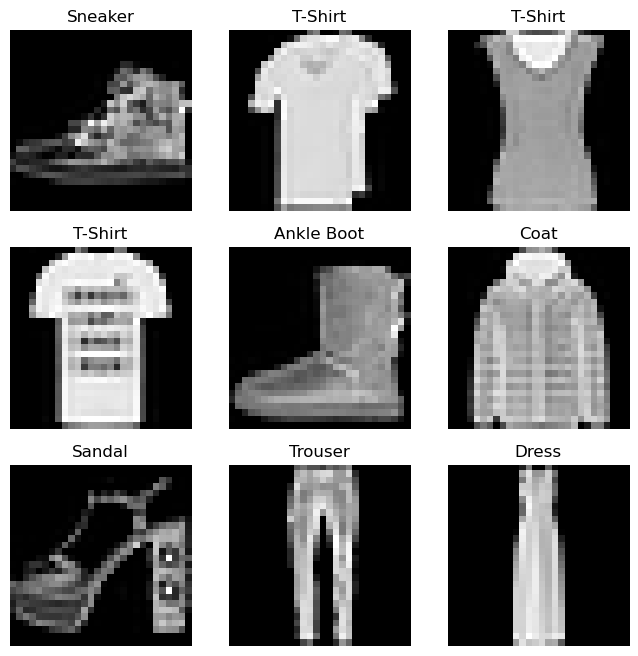

In [8]:
# Next lets iterate and visualize the dataset
# Funny enough - we can index Datasets manually like a list and vialize some samples using matplot lib
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8,8))
cols, rows = 3,3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows,cols, i)
    plt.title(labels_map[label])
    plt.axis("off") 
    plt.imshow(img.squeeze(),cmap="gray")
plt.show()

In [11]:
# we can also use Dataset for our own files
# in order to do so - our custom dataset class must implement 3 functions the __init__, the __len__, and __getitem__
# lets give it a shot

import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transfrom=None):
        self.img_labels = pd.read_csv(annotations_file) # read csv that has all the labels df looks like tshirt1.jpg, 0 ankleboot999.jpg, 9
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_lables)

    def __getitem__(self,idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx,0]) # finds location of image on disc given by idx
        image = decode_img(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


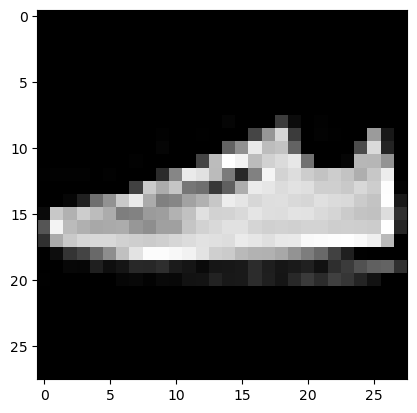

Label: 7


In [12]:
# Okay great so we have the piece that retrieves dataset features and labels one sample at a time
# however when training our model we typically want to:
# 1. pass samples in minibatches
# 2. reshuffle the datt at every epoch to reduce model overfitting
# 3. use multiprocessing to speed up data retrieval
# So what can we do about this - well that's where DataLoader comes into play
from torch.utils.data import DataLoader
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=63, shuffle=True)

# now we can iterate through batches
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")